### Demo of Matplotlib Library


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Sample data
x = np.linspace(0, 10, 50)
y = np.sin(x)
z = np.cos(x)

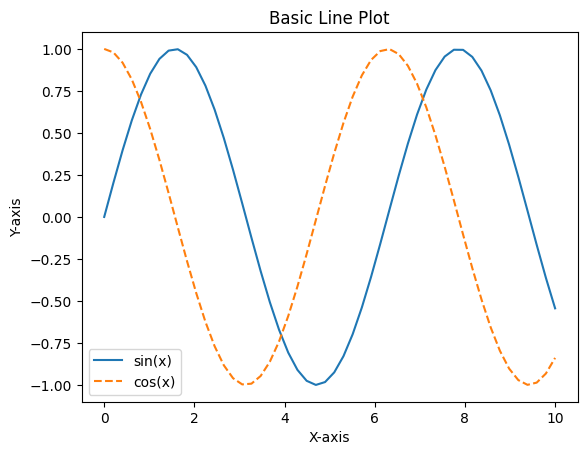

In [ ]:
# Sample Line Plot
plt.figure()    # start new plot/figure (so it doesn't overlap previous plots)
plt.plot(x, y, label="sin(x)")
plt.plot(x, z, label="cos(x)", linestyle="--")
plt.title("Basic Line Plot") # TODO: doesn't seem to actually be line plot as it's continous whereas line plot should be discrete lines?
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()   # display box in bottom of graph, showing previously registered above labels
plt.show() # Required to display the plot in non-notebook environments

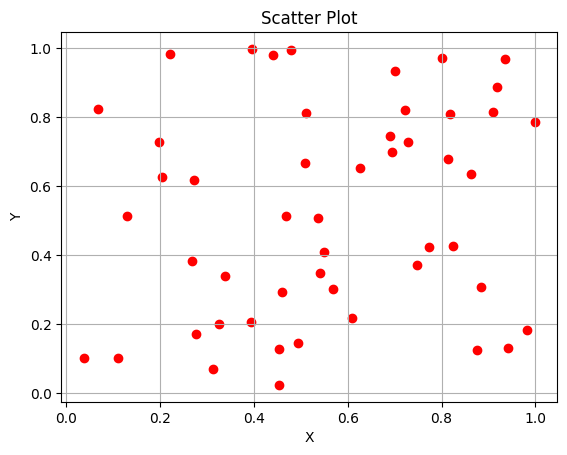

In [ ]:
# Sample Scatter Plot
x_scatter = np.random.rand(50)
y_scatter = np.random.rand(50)

plt.figure()
plt.scatter(x_scatter, y_scatter, color="red", marker="o")
plt.title("Scatter Plot")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

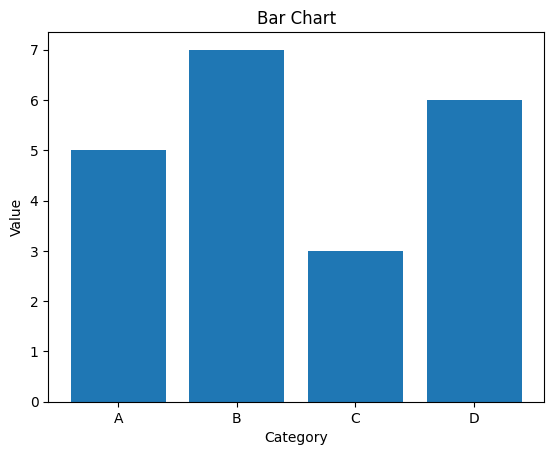

In [ ]:
# Sample Bar Plot
categories = ["A", "B", "C", "D"]
values = [5, 7, 3, 6]

plt.figure()
plt.bar(categories, values)
plt.title("Bar Chart")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()

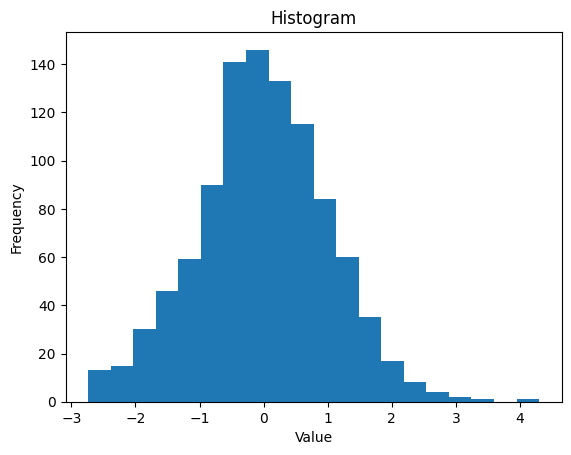

In [ ]:
# Sample Histogram

data = np.random.randn(1000)  # Normal distribution

plt.figure()
plt.hist(data, bins=20)
plt.title("Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.savefig("saved_plot.jpg")

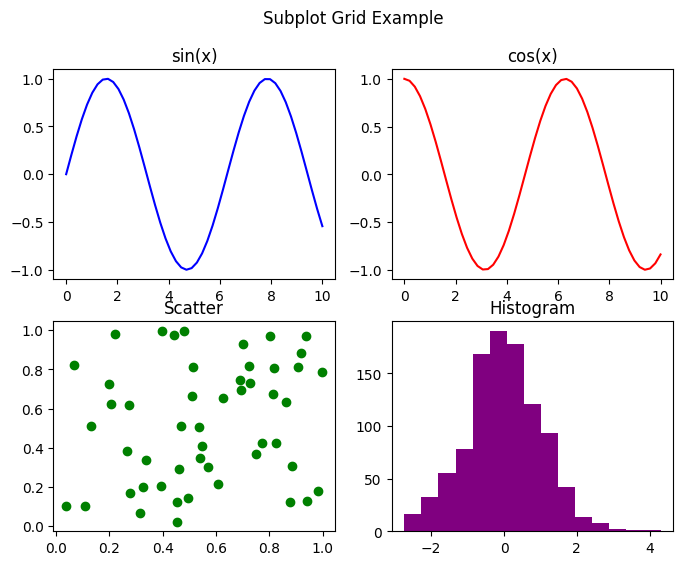

In [ ]:
# Subplots using matplotlib
f, ax = plt.subplots(2, 2, figsize=(8, 6))

ax[0,0].plot(x, y, color="blue")
ax[0,0].set_title("sin(x)")

ax[0,1].plot(x, z, color="red")
ax[0,1].set_title("cos(x)")

ax[1,0].scatter(x_scatter, y_scatter, color="green")
ax[1,0].set_title("Scatter")

ax[1,1].hist(data, bins=15, color="purple")
ax[1,1].set_title("Histogram")

f.suptitle("Subplot Grid Example")
plt.show()

### Demo of Seaborn Library


In [ ]:
# Seaborn demo with Iris dataset
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------------
# 🪷 Iris Dataset Overview
# ---------------------------------------------------------------
# The Iris dataset is one of the most famous benchmark datasets
# used for data analysis, visualization, and machine learning.
#
# It contains measurements of 150 iris flowers, belonging to
# three species:
#     1. Iris setosa
#     2. Iris versicolor
#     3. Iris virginica
#
# Each record includes four numeric features:
#     - sepal_length (cm)
#     - sepal_width  (cm)
#     - petal_length (cm)
#     - petal_width  (cm)

# Load dataset
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Set seaborn theme (global style)
sns.set_theme(style="whitegrid", palette="Set2")

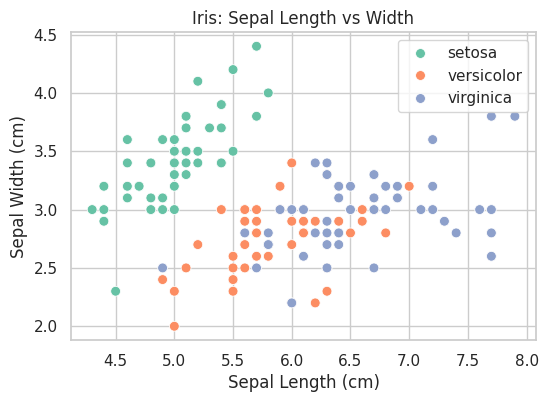

In [ ]:
# Demo of Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species",           # color by species
    # style="species",         # marker style by species
    s=50                     # marker size
)
plt.title("Iris: Sepal Length vs Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend()
plt.show()

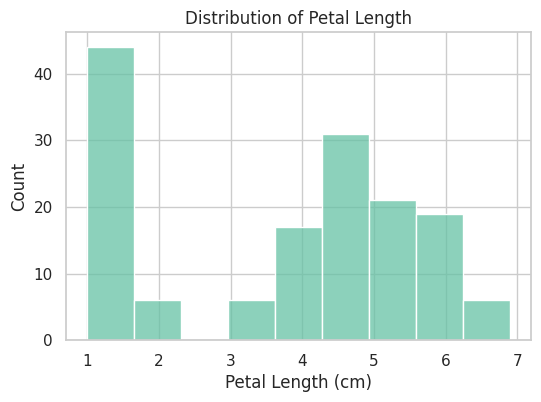

In [ ]:
# Demo of histogram
plt.figure(figsize=(6,4))
sns.histplot(df["petal_length"])
plt.title("Distribution of Petal Length")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Count")
plt.show()

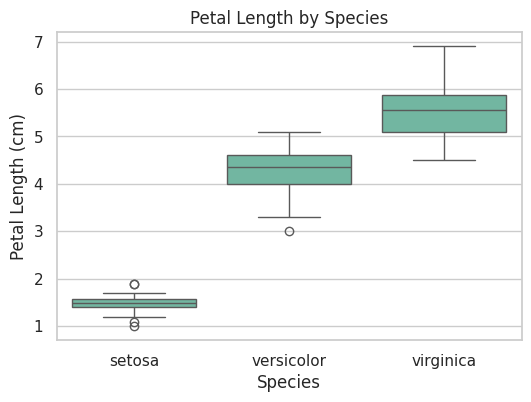

In [ ]:
# Demo of box plot
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="species", y="petal_length")
plt.title("Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")
plt.show()

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


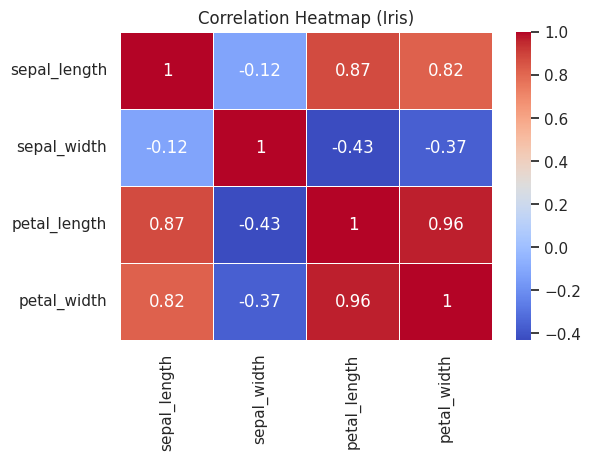

In [ ]:
# Demo of Correlation Heatmap
plt.figure(figsize=(6,4))
corr = df.select_dtypes("number").corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Iris)")
plt.show()

### Demo of Plotly


In [ ]:
import plotly.express as px
import pandas as pd

In [ ]:
# Load Iris
df = px.data.iris()

In [ ]:
# Demo of Interactive Scatter Plot
fig = px.scatter(
    df, x="sepal_length", y="sepal_width",
    color="species", symbol="species",
    hover_data=["petal_width"],
    title="Iris: Sepal Length vs Width"
)
fig.show()

In [ ]:
# Demo of grouped and stacked bar chart
# Computing average petal length and sepal length for each species
summary = df.groupby("species", as_index=False).agg({
    "sepal_length": "mean",
    "petal_length": "mean"
})
summary

,species,sepal_length,petal_length
0,setosa,5.006,1.464
1,versicolor,5.936,4.260
2,virginica,6.588,5.552


In [ ]:
# Melt the dataframe for plotting
summary = summary.melt(id_vars="species",
                       var_name="Feature",
                       value_name="Mean Value")
summary

,species,Feature,Mean Value
0,setosa,sepal_length,5.006
1,versicolor,sepal_length,5.936
2,virginica,sepal_length,6.588
3,setosa,petal_length,1.464
4,versicolor,petal_length,4.260
5,virginica,petal_length,5.552


In [ ]:
# Grouped bar chart
fig_grouped = px.bar(
    summary,
    x="species",
    y="Mean Value",
    color="Feature",
    barmode="group",
    title="Grouped Bar Chart – Mean Sepal & Petal Length by Species",
)
fig_grouped.update_layout(
    xaxis_title="Species",
    yaxis_title="Cumulative Mean Length (cm)"
)

fig_grouped.show()

In [ ]:
# Stacked bar chart
fig_stacked = px.bar(
    summary,
    x="species",
    y="Mean Value",
    color="Feature",
    barmode="stack",
    text_auto=True, # Displays the values for each bar and can be formatted as well (.2f)
    title="Stacked Bar Chart – Combined Mean Lengths by Species"
)
fig_stacked.update_layout(
    xaxis_title="Species",
    yaxis_title="Cumulative Mean Length (cm)"
)
fig_stacked.show()